In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import f_oneway


In [2]:
df_cpi = pd.read_csv("All India Consumer Price Index.csv")
df_cpi.head()

,Sector,Year,Month,Cereals and products,Meat and fish,Egg,Milk and products,Oils and fats,Fruits,Vegetables,...,Housing,Fuel and light,Household goods and services,Health,Transport and communication,Recreation and amusement,Education,Personal care and effects,Miscellaneous,General index
0,Rural,2013,January,107.5,106.3,108.1,104.9,106.1,103.9,101.9,...,NaN,105.5,104.8,104.0,103.3,103.4,103.8,104.7,104.0,105.1
1,Urban,2013,January,110.5,109.1,113.0,103.6,103.4,102.3,102.9,...,100.3,105.4,104.8,104.1,103.2,102.9,103.5,104.3,103.7,104.0
2,Rural+Urban,2013,January,108.4,107.3,110.0,104.4,105.1,103.2,102.2,...,100.3,105.5,104.8,104.0,103.2,103.1,103.6,104.5,103.9,104.6
3,Rural,2013,February,109.2,108.7,110.2,105.4,106.7,104.0,102.4,...,NaN,106.2,105.2,104.4,103.9,104.0,104.1,104.6,104.4,105.8
4,Urban,2013,February,112.9,112.9,116.9,104.0,103.5,103.1,104.9,...,100.4,105.7,105.2,104.7,104.4,103.3,103.7,104.3,104.3,104.7


In [3]:
df_cpi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Sector                               365 non-null    object 
 1   Year                                 365 non-null    int64  
 2   Month                                365 non-null    object 
 3   Cereals and products                 362 non-null    float64
 4   Meat and fish                        359 non-null    float64
 5   Egg                                  362 non-null    float64
 6   Milk and products                    362 non-null    float64
 7   Oils and fats                        362 non-null    float64
 8   Fruits                               362 non-null    float64
 9   Vegetables                           362 non-null    float64
 10  Pulses and products                  362 non-null    float64
 11  Sugar and Confectionery         

In [4]:
df_cpi.describe()

,Year,Cereals and products,Meat and fish,Egg,Milk and products,Oils and fats,Fruits,Vegetables,Pulses and products,Sugar and Confectionery,...,Clothing and footwear,Fuel and light,Household goods and services,Health,Transport and communication,Recreation and amusement,Education,Personal care and effects,Miscellaneous,General index
count,365.000000,362.000000,359.000000,362.000000,362.00000,362.000000,362.000000,362.000000,362.000000,362.000000,...,359.000000,362.000000,359.000000,362.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000
mean,2017.608219,135.964641,155.181337,140.188674,139.58232,131.341436,140.206077,155.654420,140.797238,110.711878,...,140.826184,135.625138,135.946518,137.621271,126.438162,133.167688,140.436769,132.359889,133.438997,138.807799
std,2.965449,14.205793,32.748072,22.302255,17.72663,29.694624,16.913214,28.092482,23.727066,8.970045,...,20.282839,21.526522,18.754522,23.026004,18.604797,19.636254,20.811885,22.243857,20.198469,19.831978
min,2013.000000,107.500000,106.300000,102.700000,103.60000,101.100000,102.300000,101.400000,103.500000,85.300000,...,105.800000,105.400000,104.800000,104.000000,103.200000,102.900000,103.500000,102.100000,103.700000,104.000000
25%,2015.000000,124.025000,129.800000,122.000000,128.22500,110.400000,130.175000,134.700000,119.825000,103.350000,...,124.800000,116.250000,120.800000,118.275000,111.650000,117.050000,123.350000,112.350000,116.400000,123.100000
50%,2018.000000,135.450000,143.900000,134.750000,140.80000,119.900000,140.200000,153.350000,138.300000,113.200000,...,140.800000,131.100000,134.700000,133.050000,119.400000,129.400000,139.000000,126.800000,128.900000,136.400000
75%,2020.000000,145.900000,189.750000,156.475000,153.67500,138.200000,151.750000,171.200000,164.100000,118.100000,...,152.200000,147.875000,150.100000,156.075000,139.050000,148.650000,159.150000,154.750000,149.150000,154.950000
max,2023.000000,174.700000,223.400000,197.000000,177.90000,209.900000,179.500000,245.300000,191.600000,123.900000,...,189.600000,183.200000,178.600000,186.600000,169.000000,172.800000,178.500000,181.500000,177.900000,178.000000


In [5]:
df_cpi.shape

(365, 30)

Fix column names

In [6]:
df_cpi.columns = df_cpi.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(',', '')
df_cpi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   sector                             365 non-null    object 
 1   year                               365 non-null    int64  
 2   month                              365 non-null    object 
 3   cereals_and_products               362 non-null    float64
 4   meat_and_fish                      359 non-null    float64
 5   egg                                362 non-null    float64
 6   milk_and_products                  362 non-null    float64
 7   oils_and_fats                      362 non-null    float64
 8   fruits                             362 non-null    float64
 9   vegetables                         362 non-null    float64
 10  pulses_and_products                362 non-null    float64
 11  sugar_and_confectionery            362 non-null    float64

Checking unique months

In [7]:
df_cpi["month"].unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November ', 'November',
       'December', 'Marcrh'], dtype=object)

Correcting month

In [8]:
df_cpi['month'] = (
    df_cpi['month']
    .str.strip()        
    .str.lower()       
    .replace({
        'marcrh': 'march'
    })
    .str.title()       
)
df_cpi['month'].unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

Adding Date column

In [9]:
df_cpi['date'] = pd.to_datetime(
    df_cpi['year'].astype(str) + '-' + df_cpi['month'],
    format='%Y-%B'
)
df_cpi[['year', 'month', 'date']].head(15)

,year,month,date
0,2013,January,2013-01-01
1,2013,January,2013-01-01
2,2013,January,2013-01-01
3,2013,February,2013-02-01
4,2013,February,2013-02-01
5,2013,February,2013-02-01
6,2013,March,2013-03-01
7,2013,March,2013-03-01
8,2013,March,2013-03-01
9,2013,April,2013-04-01


Convert wrong data type

In [10]:
df_cpi['housing'] = pd.to_numeric(df_cpi['housing'], errors='coerce')

Verifying columns

In [11]:
df_cpi.select_dtypes(include='object').columns

Index(['sector', 'month'], dtype='object')

Missing values

In [12]:
df_cpi.isnull().sum()

sector                                 0
year                                   0
month                                  0
cereals_and_products                   3
meat_and_fish                          6
egg                                    3
milk_and_products                      3
oils_and_fats                          3
fruits                                 3
vegetables                             3
pulses_and_products                    3
sugar_and_confectionery                3
spices                                 3
non-alcoholic_beverages                3
prepared_meals_snacks_sweets_etc.      6
food_and_beverages                     3
pan_tobacco_and_intoxicants            6
clothing                               6
footwear                               6
clothing_and_footwear                  6
housing                              124
fuel_and_light                         3
household_goods_and_services           6
health                                 3
transport_and_co

Sorting values

In [13]:
df_cpi = df_cpi.sort_values(['sector', 'date'])

Filling null values

In [14]:
num_cols = df_cpi.select_dtypes(include='number').columns

df_cpi[num_cols] = df_cpi.groupby('sector')[num_cols].transform(
    lambda x: x.interpolate(method='linear')
)

df_cpi.bfill(inplace=True)
df_cpi.ffill(inplace=True)
df_cpi.isnull().sum()

sector                               0
year                                 0
month                                0
cereals_and_products                 0
meat_and_fish                        0
egg                                  0
milk_and_products                    0
oils_and_fats                        0
fruits                               0
vegetables                           0
pulses_and_products                  0
sugar_and_confectionery              0
spices                               0
non-alcoholic_beverages              0
prepared_meals_snacks_sweets_etc.    0
food_and_beverages                   0
pan_tobacco_and_intoxicants          0
clothing                             0
footwear                             0
clothing_and_footwear                0
housing                              0
fuel_and_light                       0
household_goods_and_services         0
health                               0
transport_and_communication          0
recreation_and_amusement 

Filling missing values using forward fill

In [15]:
df_cpi = df_cpi.ffill()
print(df_cpi.isnull().sum())

sector                               0
year                                 0
month                                0
cereals_and_products                 0
meat_and_fish                        0
egg                                  0
milk_and_products                    0
oils_and_fats                        0
fruits                               0
vegetables                           0
pulses_and_products                  0
sugar_and_confectionery              0
spices                               0
non-alcoholic_beverages              0
prepared_meals_snacks_sweets_etc.    0
food_and_beverages                   0
pan_tobacco_and_intoxicants          0
clothing                             0
footwear                             0
clothing_and_footwear                0
housing                              0
fuel_and_light                       0
household_goods_and_services         0
health                               0
transport_and_communication          0
recreation_and_amusement 

Checking dplicates

In [16]:
df_cpi.duplicated().sum()

np.int64(0)

Overall inflation trend

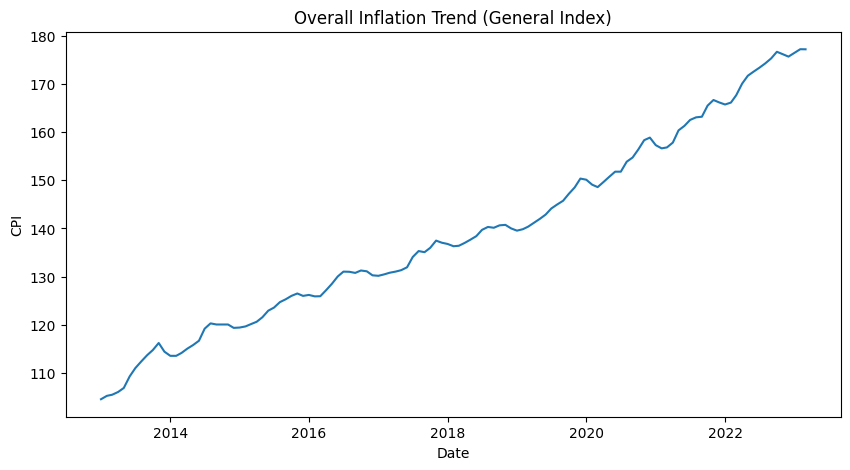

In [ ]:
df_general = df_cpi.groupby('date')['general_index'].mean()

plt.figure(figsize=(10,5))
plt.plot(df_general)
plt.title("Overall Inflation Trend (General Index)")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.show()

The general CPI index shows a sustained upward trend, indicating continuous inflation, with accelerated growth in the post-2020 period.

Sector wise Comparison

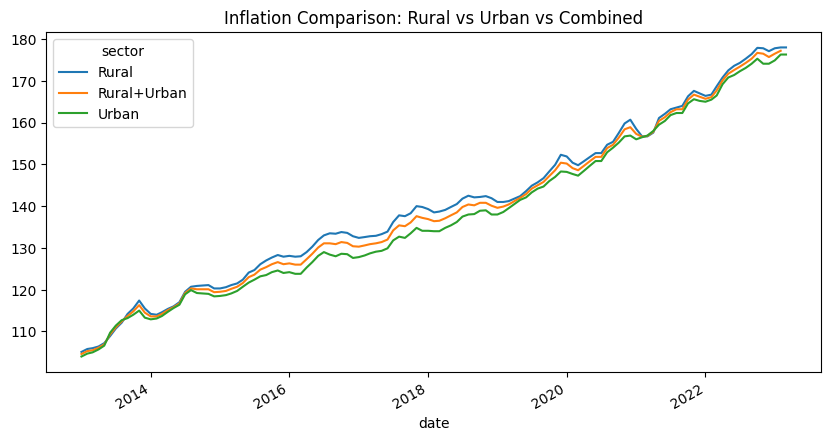

In [94]:
df_sector = df_cpi.groupby(['date','sector'])['general_index'].mean().unstack()

df_sector.plot(figsize=(10,5))
plt.title("Inflation Comparison: Rural vs Urban vs Combined")
plt.show()

Heatmap for most volatile commodities

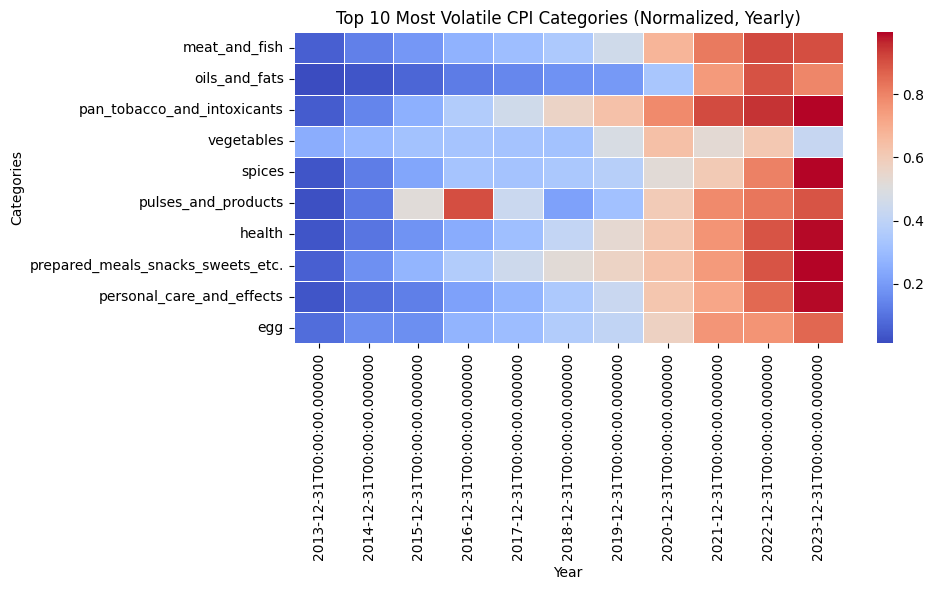

In [ ]:
# Step 1: Get category columns
cols = df_cpi.columns.drop(['year', 'month', 'date', 'sector'])

# Step 2: Group by date
df_cat = df_cpi.groupby('date')[cols].mean()

# Step 3: Normalize (fix scaling issue)
df_norm = (df_cat - df_cat.min()) / (df_cat.max() - df_cat.min())

# Step 4: Reduce clutter (yearly aggregation)
df_yearly = df_norm.resample('YE').mean()

# Step 5: Keep only top 10 most volatile categories (clean view)
top10 = df_cat.std().sort_values(ascending=False).head(10).index

# Step 6: Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df_yearly[top10].T, cmap='coolwarm', linewidths=0.5)

plt.title("Top 10 Most Volatile CPI Categories (Normalized, Yearly)")
plt.xlabel("Year")
plt.ylabel("Categories")

plt.tight_layout()
plt.show()

Most volatile categoories

In [105]:
cols = df_cpi.columns.drop(['year','month','date','sector'])

df_cat = df_cpi.groupby('date')[cols].mean()

volatility = df_cat.std().sort_values(ascending=False)

top5 = volatility.head(5)

print(top5)

meat_and_fish                  32.750600
oils_and_fats                  29.415514
pan_tobacco_and_intoxicants    29.179109
vegetables                     26.547310
spices                         25.448625
dtype: float64


Top 5 most volatile CPI categories

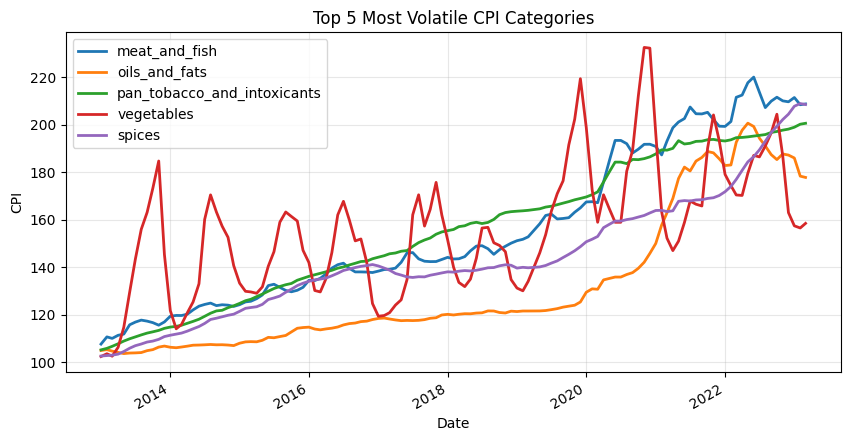

In [106]:
df_cat[top5.index].plot(figsize=(10,5), linewidth=2)

plt.title("Top 5 Most Volatile CPI Categories")
plt.xlabel("Date")
plt.ylabel("CPI")

plt.grid(alpha=0.3)
plt.show()

Month-on-Month (MoM) Inflation : How much prices changed compared to the previous month

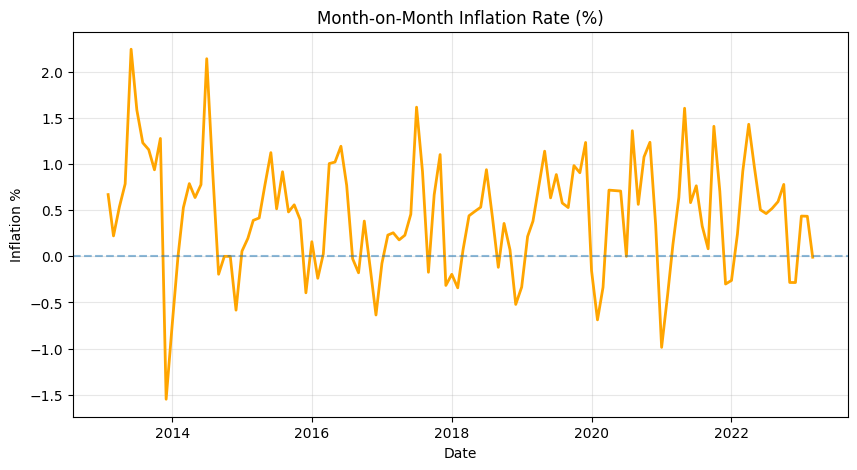

In [108]:
df_general = df_cpi.groupby('date')['general_index'].mean()

mom_inflation = df_general.pct_change() * 100
plt.figure(figsize=(10,5))
plt.plot(mom_inflation, color='orange', linewidth=2)

plt.title("Month-on-Month Inflation Rate (%)")
plt.xlabel("Date")
plt.ylabel("Inflation %")

plt.axhline(0, linestyle='--', alpha=0.5)  # reference line
plt.grid(alpha=0.3)
plt.show()

Year-on-Year (YoY) Inflation : Long-term trend

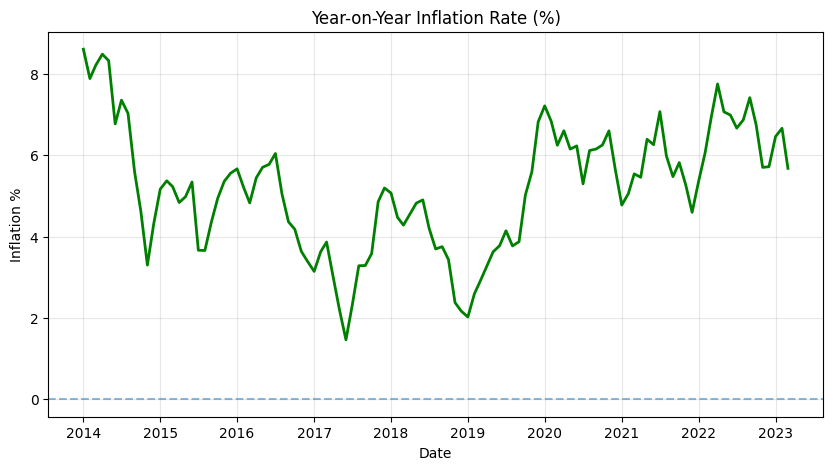

In [109]:
yoy_inflation = df_general.pct_change(periods=12) * 100
plt.figure(figsize=(10,5))
plt.plot(yoy_inflation, color='green', linewidth=2)

plt.title("Year-on-Year Inflation Rate (%)")
plt.xlabel("Date")
plt.ylabel("Inflation %")

plt.axhline(0, linestyle='--', alpha=0.5)
plt.grid(alpha=0.3)
plt.show()

Highest and lowest inflation

In [113]:
max_date = mom_inflation.idxmax()
max_value = mom_inflation.max()

min_date = mom_inflation.idxmin()
min_value = mom_inflation.min()

print(f"Highest MoM Inflation:")
print(f"Month: {max_date.strftime('%B %Y')}")
print(f"Value: {max_value:.2f}%\n")

print(f"Lowest MoM Inflation (Deflation):")
print(f"Month: {min_date.strftime('%B %Y')}")
print(f"Value: {min_value:.2f}%")

Highest MoM Inflation:
Month: June 2013
Value: 2.25%

Lowest MoM Inflation (Deflation):
Month: December 2013
Value: -1.55%


Correlation of sectors with inflation

Recreation And Amusement             0.996046
Miscellaneous                        0.995523
Food And Beverages                   0.994369
Health                               0.993798
Household Goods And Services         0.993309
Prepared Meals Snacks Sweets Etc.    0.991520
Clothing                             0.990632
Clothing And Footwear                0.990356
Personal Care And Effects            0.989483
Milk And Products                    0.985521
Footwear                             0.985376
Pan Tobacco And Intoxicants          0.984585
Education                            0.982973
Non-Alcoholic Beverages              0.982181
Fuel And Light                       0.980827
Meat And Fish                        0.980111
Housing                              0.977059
Spices                               0.975539
Cereals And Products                 0.973722
Transport And Communication          0.968861
Name: general_index, dtype: float64


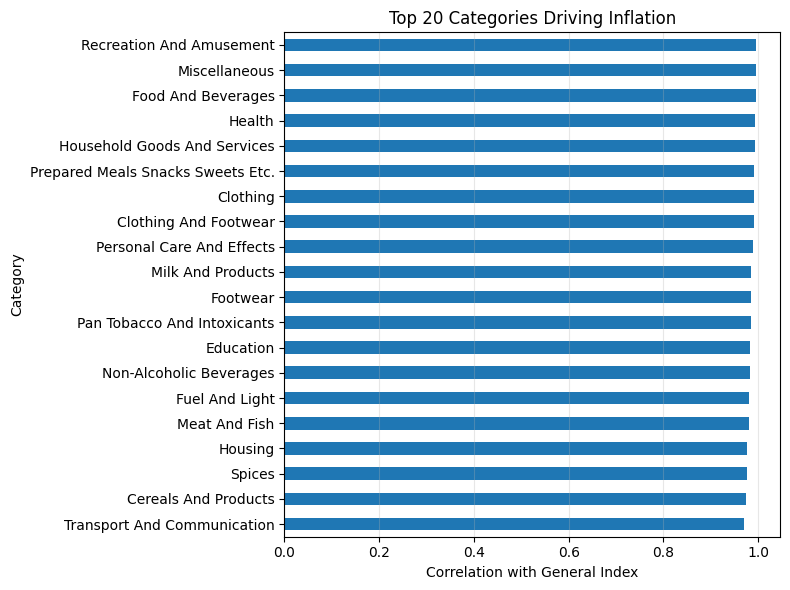

In [119]:
cols = df_cpi.columns.drop(['year','month','date','sector'])
df_cat = df_cpi.groupby('date')[cols].mean()
corr = df_cat.corr()['general_index'].sort_values(ascending=False)

top20 = corr.drop('general_index').head(20)
top20.index = top20.index.str.replace('_', ' ').str.title()
print(top20)
plt.figure(figsize=(8,6))
top20.sort_values().plot(kind='barh')

plt.title("Top 20 Categories Driving Inflation")
plt.xlabel("Correlation with General Index")
plt.ylabel("Category")

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Volatility Analysis : Measure how stable or unstable inflation is over time

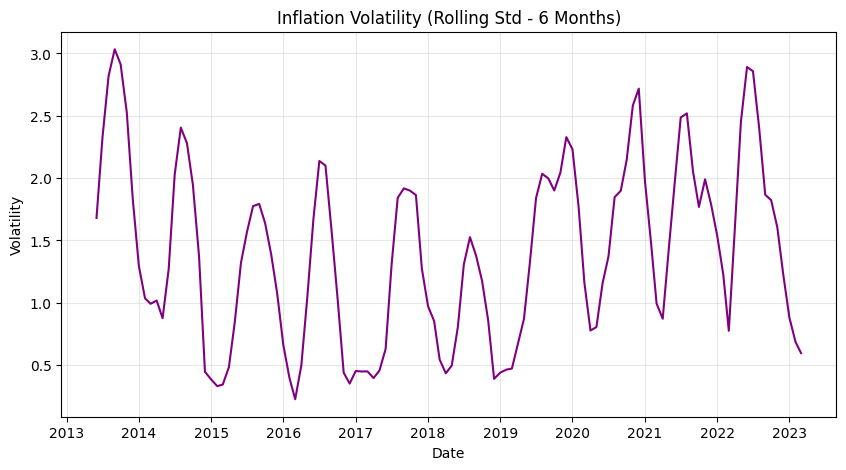

In [120]:
rolling_std = df_general.rolling(window=6).std()

plt.figure(figsize=(10,5))
plt.plot(rolling_std, color='purple')

plt.title("Inflation Volatility (Rolling Std - 6 Months)")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(alpha=0.3)
plt.show()

T-Test (Urban vs Rural)

In [124]:
urban = df_cpi[df_cpi['sector']=='Urban']['general_index']
rural = df_cpi[df_cpi['sector']=='Rural']['general_index']

t_stat, p_val = ttest_ind(urban, rural)

print("T-stat:", t_stat)
print("P-value:", p_val)

T-stat: -1.017940960605015
P-value: 0.3097226031630189


0.3097 > 0.05
The t-test comparing urban and rural inflation yields a p-value of 0.3097, which is greater than 0.05. This indicates that there is no statistically significant difference between urban and rural inflation levels.


ANOVA test 

In [128]:
urban = df_cpi[df_cpi['sector']=='Urban']['general_index'].dropna()
rural = df_cpi[df_cpi['sector']=='Rural']['general_index'].dropna()
combined = df_cpi[df_cpi['sector']=='Rural+Urban']['general_index'].dropna()

f_stat, p_val = f_oneway(urban, rural, combined)

print("F-stat:", f_stat)
print("P-value:", p_val)

F-stat: 0.5269663303010578
P-value: 0.5908455060570836


The ANOVA test across rural, urban, and combined sectors yields a p-value of 0.5908, which is greater than 0.05. This indicates that there is no statistically significant difference in inflation levels across sectors